# Assignment 4 – Robot in a maze

In the  fourth assignment, you will delve into the application of RL algorithms to address the real-world challenge of navigating a robot through a maze dubbed 'robot in a maze'. The primary objectives of this assignment include:

 -   Formalizing a practical problem into a Markov Decision Process (MDP).
 -   Gaining familiarity with the OpenAI Gym framework (recently renamed as Gymnasium) and utilizing it to implement RL agents.
 -   Applying SARSA and Q-learning algorithms to solve the 'robot in a maze' MDP problem.
 -   Evaluating the outcomes of the reinforcement learning process and interpreting your findings.
 -   Reflecting on the distinctions between the two types of RL algorithms employed.

By accomplishing these objectives, you will not only enhance your understanding of RL algorithms but also develop practical skills in formulating and solving complex problems in the context of autonomous navigation within a maze.

In this assignment, you will be developing a robot to navigate its way through a maze. The project is divided into three parts (5 subtasks).

  1. In the first part, you will familiarize yourself with the OpenAI Gym/Gymnasium framework.
  2. In the second part, we have implemented the environment for you based on the Gym/Gymnasium framework. Your tasks include:  
     2.1. formalizing the problem as an MDP model,    
     2.2. implementing your own RL agents, and      
     2.3. training them to find the shortest route out of a maze.
  3. Finally, in the third part, you will evaluate and interpret the results obtained from the implemented RL agents


## 1. OpenAI gym

Gym/Gymnasium (https://gymnasium.farama.org/) is a widely used standard toolkit for developing and comparing reinforcement learning algorithms. Gymnasium is the maintained fork of OpenAI’s Gym library (more on this recent change is available if you're interested: https://farama.org/Announcing-The-Farama-Foundation).

Gym/Gymnasium makes no assumptions about the structure of your agent and is compatible with any machine learning library, such as TensorFlow or Theano.

The library is a collection of test problems — environments — that you can use to develop your reinforcement learning algorithms. These environments have a shared interface, allowing you to write general algorithms.

First, we download and install the Gym/Gymnasium library. Then, import the Gymnasium class.

In [1]:
!pip install gymnasium



[notice] A new release of pip is available: 23.1.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


We are now going to explain how the RL framework of gym works. 
- An **ENVIRONMENT**, 
- You also have an **AGENT**,
- In MDP problems, such as ours, the **ENVIRONMENT** provides an **OBSERVATION**, which represents the state of the **ENVIRONMENT** at the current moment.
- The agent takes an **ACTION** based on its **OBSERVATION**,
<!-- When a single **ACTION** is chosen and fed to our **ENVIRONMENT**, the **ENVIRONMENT** measures how good the action was taken and produces a **REWARD**, which is usually a numeric value. -->
- When the agent takes an ACTION, the ENVIRONMENT assesses the effectiveness of the action and generates a REWARD, which is usually a numeric value.

Please read the 'Basic usage' https://gymnasium.farama.org/content/basic_usage/ for better understanding the framework.  And do not forget import gymnasium before running other codes.

In [2]:
import gymnasium as gym

 ## 2. Tasks

Next, you will tackle a practical Markov Decision Process (MDP) problem, the 'robot in a maze,' based on the gym framework. Your task involves implementing an RL agent and training it to discover the shortest route to achieve the maze goal. In this MDP, the environment is represented as a grid world (a maze), with the agent being a robot. At each time step, the robot begins at a random location and can move within the grid world. The overarching objective is to find the way out, reaching the final location. Consequently, you will need to identify a fixed goal position within the maze.

### 2.1 Model the practical task into a MDP

To solve a RL problem, we start with formalizing the problem into a MDP model. Please describe this MDP model in your report. 

Notice: No empricial data provided in this assignment, so the point of 'data description and exploration' will be given to this step. 

While exploring your MDP model, you shall think about questions such as:
- What is the environment? How does it look like?
- What simulated data can your RL agent observe from the environment? How does it look like?
- Which data is considered as the state? Which data is considered as the reward?

#### Set up the environment

There is no need to implement your own environment; you should use the environment provided in the file **environment.py**. However, please ensure to take a look at it so that you understand the inner workings of this environment.

The core gym interface is **Env**, which serves as the unified environment interface. The following are the Env methods you should be familiar with:

- reset(self): Reset the environment's state and return the observation.
- step(self, action): Advance the environment by one timestep and return the observation, reward, done, and info.
- render(self, mode='rgb_array'): Render one frame of the environment. The default mode will produce something human-friendly, such as a pop up window. However, in this assignment, there is no need to create a pop-up window.

Please note that you need to install the [mazelab](https://github.com/yupei-du/mazelab.git) package, from **Yupei Du's** repository, to run the environment (a file with required packages is also provided). If you run the cell below for the first time, make sure to restart the IPython notebook at least once.


In [3]:
!git clone https://github.com/yupei-du/mazelab.git
!pip install -e mazelab
!pip install pandas
!pip install seaborn

fatal: destination path 'mazelab' already exists and is not an empty directory.


Obtaining file:///C:/Users/casbo/OneDrive/KI%202022-2023/Applications%20of%20Machine%20Learning/Nieuwe%20map/mazelab
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Attempting uninstall: mazelab
    Found existing installation: mazelab 0.2.0
    Uninstalling mazelab-0.2.0:
      Successfully uninstalled mazelab-0.2.0
  Running setup.py develop for mazelab



[notice] A new release of pip is available: 23.1.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.1.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.1.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


You can now check whether the required packages (e.g. mazela, pandas, tqdm, seaborn) are installed. Please install the ones are missing. 

ATTENTION: To run the given code, please use the python version 3.7-3.9, and the numpy version < 1.23

In [4]:
conda list

# packages in environment at c:\Users\casbo\anaconda3:
#
# Name                    Version                   Build  Channel
_ipyw_jlab_nb_ext_conf    0.1.0            py39haa95532_0  
absl-py                   1.1.0                    pypi_0    pypi
aiohttp                   3.8.1            py39h2bbff1b_1  
aiosignal                 1.2.0              pyhd3eb1b0_0  
alabaster                 0.7.12             pyhd3eb1b0_0  
anaconda                  2022.05                  py39_0  
anaconda-client           1.9.0            py39haa95532_0  
anaconda-navigator        2.2.0            py39haa95532_0  
anaconda-project          0.10.2             pyhd3eb1b0_0  
anyio                     3.5.0            py39haa95532_0  
appdirs                   1.4.4              pyhd3eb1b0_0  
argon2-cffi               21.3.0             pyhd3eb1b0_0  
argon2-cffi-bindings      21.2.0           py39h2bbff1b_0  
arrow                     1.2.2              pyhd3eb1b0_0  
astroid                   2.6.

We also provide a few helper functions to make it easier to debug your agents. 
 - `animate_run` will enable you to see the agent's behavior. It takes a list of images which can be produced by the `env.render` function of the environment
 - `visualize_agent_brain` will provide you with a way to visualize the agents learned q_table. Use it after you have implemented and trained your agents. The first plot will show the highest q-value per state (position on the map) and the second will tell you which action the agent would choose at that state/position. It takes the environment and the agent as input.

Below you will find a basic example of how the animation function works. Please notice that: whenever you **reset()** the environment, the agent will start at a random position (a different state). 

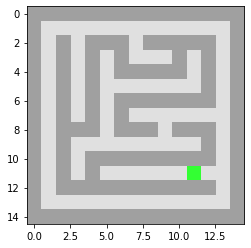

In [5]:
# The helper functions

from IPython import get_ipython
import random
from mazelab.generators import random_maze, morris_water_maze
import matplotlib.pyplot as plt
from IPython import display
from mazelab.solvers import dijkstra_solver
import seaborn as sns
from tqdm.notebook import tqdm
from environment import TaskEnv
from typing import Tuple, List
import itertools as it
import numpy as np
import pandas as pd

def animate_run(data:List[np.ndarray]):
    init_img = data[0]
    remaining_img = data[1:]
    img_container = plt.imshow(init_img)  # only call this once
    for img in remaining_img:
        img_container.set_data(img)  # just update the data
        display.display(plt.gcf())
        display.clear_output(wait=True)


def visualize_agent_brain(agent, env: TaskEnv):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.set_title("Highest state value at position (x,y)")
    state_value_map = agent.q_table.max(axis=2)
    sns.heatmap(state_value_map, ax=ax1)

    ax2.set_title("Chosen action at position (x,y)")
    n = env.action_space.n + 1
    path = env.maze.objects.free.positions
    decisions_map = np.array([[x_, y_, agent.select_action([x_, y_]) + 1] for x_, y_ in path])
    state_action_map = np.zeros_like(agent.q_table.max(axis=2))
    state_action_map[decisions_map[:, 0], decisions_map[:, 1]] = decisions_map[:, 2]
    cmap = sns.color_palette("viridis", n)
    sns.heatmap(state_action_map, cmap=cmap, ax=ax2)
    colorbar = ax2.collections[0].colorbar
    r = (colorbar.vmax) - colorbar.vmin
    colorbar.set_ticks([colorbar.vmin + r / n * (0.5 + i) for i in range(n)])
    colorbar.set_ticklabels(['N/A', 'north', 'south', 'west', 'east'])
    fig.tight_layout()
    return plt.show()


env = TaskEnv()
env.reset()
impassable_array = env.unwrapped.maze.to_impassable()
motions = env.unwrapped.motions
start = env.unwrapped.maze.objects.agent.positions[0]
goal = env.unwrapped.maze.objects.goal.positions[0]
actions = dijkstra_solver(impassable_array, motions, start, goal)
print(actions)

imgs = []
rewards = 0.0
for action in actions:
    _, reward, _, _ = env.step(action)
    rewards += reward
    imgs.append(env.render("rgb_array"))
print(rewards)

animate_run(imgs)
plt.show()

### 2.2  Implement the agents 

In this part, you are expected to implement two RL agents. 

- Agent 1 uses the Q-learning algorithm to learn the optimal solution
- Agent 2 uses the SARSA algorithm to learn the optimal solution. To decide the action to take at each time step,  this agent uses the epsilon greedy action selection.

Here, we have also provided an example agent: the Random Agent.  It follows a random policy to move at each step (randomly selecting an action). You can use this example agent as a baseline to evaluate your agents.


In [6]:
# TODO: implement two agents
# Random agent
class RandomAgent():
    def __init__(self,
                 env: TaskEnv,
                 exploration_rate: float = 1,
                 learning_rate: float = 0,
                 discount_factor: float = 0,
                 max_steps: int = None) -> int:
        self.epsilon = exploration_rate # A random agent "explores" always, so epsilon will be 1
        self.alpha = learning_rate  # A random agent never learns, so there's no need for a learning rate
        self.gamma = discount_factor  # A random agent does not update it's q-table. Hence, it's zero.
        self.q_table = np.zeros(env.observation_space.shape + (env.action_space.n,), dtype=float) 
        self.actions = env.action_space
        self.max_steps = max_steps

    def select_action(self, state: Tuple[int, int], use_greedy_strategy: bool = False) -> int:
        if not use_greedy_strategy:
            if random.random() < self.epsilon:
                next_action = self.actions.sample()
                return next_action

        x, y = state
        return np.argmax(self.q_table[x, y, :])

    def learn(self, state, action, next_state, next_action, reward, done):
        x, y = state
        x_, y_ = next_state
        self.q_table[x, y, action] += self.alpha * (reward + self.gamma * self.q_table[x_, y_, next_action] - self.q_table[x, y, action])
        return None

    def train(self,env : TaskEnv,episodes: int):
        rewards = []
        for episode in range(episodes):
            state = env.reset()
            action = self.select_action(state)
            total_reward = 0
            total_steps = 0
            for step in range(self.max_steps):
                next_state, reward, done, _ = env.step(action)
                total_reward += reward
                total_steps += 1
                next_action = self.select_action(next_state)
                self.learn(state, action, next_state, next_action, reward, done)
                state = next_state
                action = next_action
                if done:
                    break
            rewards.append(total_reward)
        return rewards

    def test(self, env: TaskEnv, episodes: int):
        rewards = []
        for episode in range(episodes):
            state = env.reset()
            total_reward = 0
            for step in range(self.max_steps):
                action = self.select_action(state, use_greedy_strategy=True)
                state, reward, done, _ = env.step(action)
                total_reward += reward
                if done:
                    break
            rewards.append(total_reward)
        return np.mean(rewards)

    def visualize(self,max_steps : int = 100):
        imgs = []
        state = env.reset()
        for _ in range(max_steps):
            action = self.select_action(state, use_greedy_strategy=True)
            state, _, done, _ = env.step(action)
            imgs.append(env.render("rgb_array"))
            if done:
                break
        return imgs

# SARSA agent
class SARSA_eps_greedy(RandomAgent):
    def train(self, env: TaskEnv, episodes: int):
        rewards = []
        for episode in range(episodes):
            state = env.reset()
            action = self.select_action(state)
            total_reward = 0
            total_steps = 0
            for step in range(self.max_steps):
                next_state, reward, done, _ = env.step(action)
                total_reward += reward
                total_steps += 1
                next_action = self.select_action(next_state)
                self.learn(state, action, next_state, next_action, reward, done)
                state = next_state
                action = next_action
                if done:
                    break
            rewards.append(total_reward)
        return rewards

#Q-Learning agent
class Q_Learning(RandomAgent):
    def train(self, env: TaskEnv, episodes:int, keepPosition = False):
        rewards = []

        initial_state = env.reset()
        for episodes in range(episodes):
            state = env.restart_run(initial_state) if keepPosition else env.reset()
            action = self.select_action(state)
            total_reward = 0
            total_steps = 0
            for step in range(self.max_steps):
                next_state,reward,done,_ = env.step(action)
                total_reward += reward
                total_steps += 1
                optimal_action = self.select_action(next_state,True)
                
                self.learn(state,action,next_state,optimal_action,reward,done)
                state = next_state
                action = self.select_action(state)
                if done:
                    break
            rewards.append(total_reward)
        return rewards
    
class Monte_Carlo(RandomAgent):
    def __init__(self,env:TaskEnv, exploration_rate: float, decay_rate: float, discount_factor: float, max_steps: int):
        super().__init__(env, exploration_rate, decay_rate, discount_factor, max_steps)
        self.returns = {}
    
    def learn_first_visit(self,episode,incremental = True):
        visited = set()
        for state,action,g_t in episode:
            x,y = state
            if (x,y,action) not in visited:
                visited.add((x,y,action))
                if ((x,y,action) not in self.returns):
                    self.returns[(x,y,action)] = [g_t,1]
                else:
                    self.returns[(x,y,action)][0] += g_t
                    self.returns[(x,y,action)][1] += 1
                
                if incremental:
                    learning_rate = self.alpha * 1 / len(self.returns[(x,y,action)])
                    self.q_table[(x,y,action)] += learning_rate * (g_t - self.q_table[(x,y,action)])
                else:
                    self.q_table[(x,y,action)] = self.returns[(x,y,action)][0]/self.returns[(x,y,action)][0]

    def learn_every_visit(self,episode,incremental):
        
        for state,action,g_t in episode:
            x,y = state
            if ((x,y,action) not in self.returns):
                    self.returns[(x,y,action)] = [g_t,1]
            else:
                self.returns[(x,y,action)][0] += g_t
                self.returns[(x,y,action)][1] += 1
            
            if incremental:
                learning_rate = self.alpha * 1 / len(self.returns[(x,y,action)])
                self.q_table[(x,y,action)] += learning_rate * (g_t - self.q_table[(x,y,action)])
            else:
                self.q_table[(x,y,action)] = self.returns[(x,y,action)][0]/self.returns[(x,y,action)][0]

    def train(self, env: TaskEnv, episodes: int,method: int = 0):
        
        rewards = []
        for nthEpisode in range(episodes):
            episode = []
            state=env.reset()
            for step in range(self.max_steps):
                action = self.select_action(state)
                next_state, reward, done,_ = env.step(action)
                episode.append((state,action,reward))
                state = next_state
                if done:
                    break
            preprocess_states = []
            g = 0
            for state,action,reward in reversed(episode):
                g = reward + self.gamma * g
                preprocess_states.append((state,action,g))
            
            preprocess_states.reverse()
            if method == 1:
                self.learn_first_visit(preprocess_states, False)
            elif method == 2:
                self.learn_every_visit(preprocess_states, False)
            elif method == 3:
                self.learn_first_visit(preprocess_states, True)
            else:
                self.learn_every_visit(preprocess_states, True)

            self.learn_first_visit(preprocess_states,True)
            rewards.append(sum([reward for _, _, reward in episode]))

            self.epsilon = 1 / max((nthEpisode * 0.1),0.01)
        return rewards




In [7]:
print(list(reversed(range(0,10))))

[9, 8, 7, 6, 5, 4, 3, 2, 1, 0]


### 2.3 Run the simulation

Now, you write code for running a simulation. In each run, you shall setup the epsilon parameter. 

In [8]:
# TODO: run the simulation

def train_test(env,agentType: RandomAgent,epsilon,learning_rate,gamma,max_steps):
    agent = agentType(env,epsilon,learning_rate,gamma,max_steps)
    training_rewards = agent.train(env,episodes=10000)
    test_rewards = agent.test(env,episodes = 1000)
    imgs = agent.visualize()
    return training_rewards,test_rewards, agent, imgs

In [9]:
env = TaskEnv()

In [10]:
Q_learning_rewards,Q_test_rewards, Q_agent, Q_imgs = train_test(env,Q_Learning,0.1,0.01,0.9,1000)
SARSA_learning_rewards,SARSA_test_rewards,SARSA_agent,SARSA_imgs = train_test(env,SARSA_eps_greedy,0.1,0.01,0.9,1000)
MC_learning_rewards,MC_test_rewards, MC_agent, MC_imgs = train_test(env,Monte_Carlo,1,0.01,0.9,1000)

In [11]:
print(MC_learning_rewards)

[-74.15, -77.05, -77.17000000000003, -57.1, -73.69, -37.2, -80.76000000000002, -82.37999999999998, -72.16000000000001, -71.38999999999999, -74.77000000000002, -68.18000000000002, -77.07, -75.00000000000001, -77.96999999999998, -81.66000000000003, -82.80999999999999, -25.53, -78.06000000000002, -85.82, -61.220000000000006, -86.03999999999999, -92.38, -78.81, -86.8, -69.71, -84.62, -87.17000000000002, -72.55999999999999, -83.50000000000001, -91.90999999999998, -89.22000000000003, -93.49, -97.62999999999998, -91.08999999999999, -84.95999999999998, -91.43, -82.35, -92.75, -60.849999999999994, -59.69, -63.51, -86.93999999999998, -74.53999999999998, -83.64999999999999, -95.02, -92.80000000000001, -57.65, -92.57000000000002, -91.47, -73.55, -88.28999999999999, -82.68, -96.70999999999998, -68.84, -61.29, -94.72, -94.7, -53.760000000000005, -90.10000000000001, -91.41000000000001, -93.95, -77.94, -96.98, -98.27000000000001, -64.84, -93.02, -93.71, -95.23, -57.480000000000004, -81.67, -96.9299999

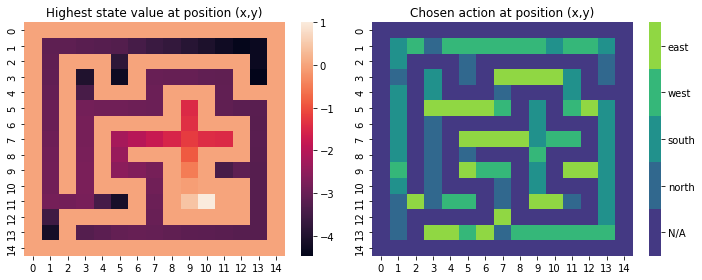

In [12]:
visualize_agent_brain(SARSA_agent,env)
plt.show()

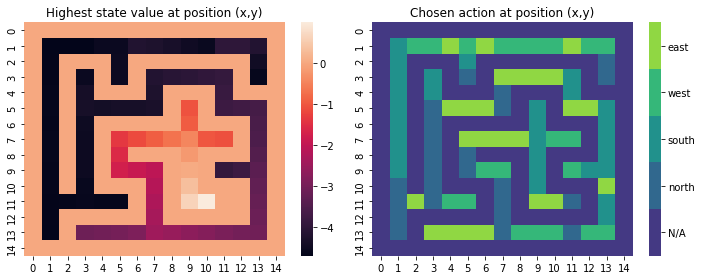

In [13]:
visualize_agent_brain(Q_agent,env)
plt.show()


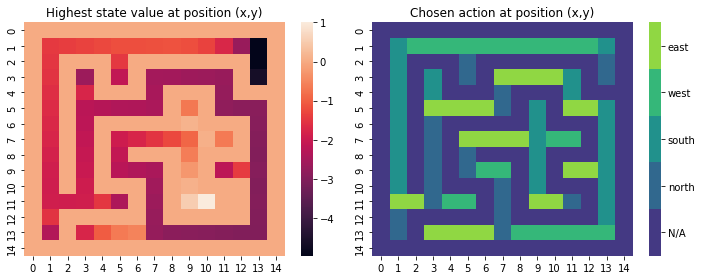

In [14]:
visualize_agent_brain(MC_agent,env)
plt.show()

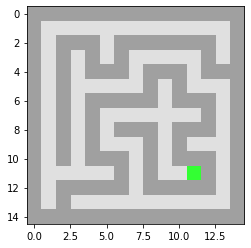

In [15]:
animate_run(SARSA_imgs)
plt.show()

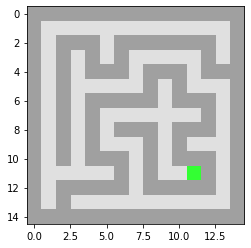

In [16]:
animate_run(Q_imgs)
plt.show()

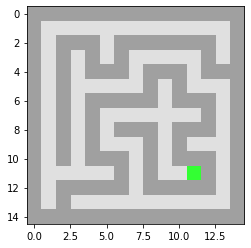

In [17]:
animate_run(MC_imgs)
plt.show()

 ## 3. Play with parameters and analyse results
 
Finally, you will describe, evaluate, and interpret the results obtained from the two RL agents. Additionally, compare your agents with the provided Random Agent. Feel free to utilize the provided helper functions for evaluating your agents. Some important points are:

- Both quantified evaluation and human evaluation are needed in the report. The quantified evaluation should focus on the measurement of reward. In the human evaluation, you can use the provided visual tools to interpret your results. Your report should include at least one plot presenting comparable measures for the different agents.

- While evaluating the results of Agent 2 (with SARSA algorithm), please try at least 2 different values of **epsilon** (expect 0) and discuss the influence of different epsilon values on the results. In the end, please identify a reasonable epsilon value that could balance the exploration and exploitation, then fix this value for comparing the two agents. Present your trails and results in the report.

- In the report, you also need to parcitularly describe and discuss the similarity and difference of results from two RL agents (hint: on-policy VS off-policy). For this, please make sure that the compared results are obtained from the same environment (the same maze for two different agents). Also, while evaluating the results of two agents, please try at least 2 different values of **gamma**. In this way, you could discuss the influence of this discount factor in your report. 

- Please run the simulation multiple times and average the results for all your findings.


In [18]:
# TODO: evaluation 
# keep the environment fixed
env = TaskEnv()

# SARSA
gamma_values = [0.8, 0.9, 1.0]
for gamma in gamma_values:
    print('-'*10 + f' gammma = {gamma} ' + '-'*10)
    epsilon_values = [0.05, 0.1, 0.2]
    results = []
    for epsilon in epsilon_values:
        SARSA_training_rewards,SARSA_test_rewards, SARSA_agent,_ = train_test(env,SARSA_eps_greedy,epsilon,0.05,gamma,200)
        print(f"Average SARSA agent reward with epsilon={epsilon}: {SARSA_test_rewards:.2f}")
        results.append([SARSA_test_rewards, SARSA_agent])
    max_SARSA_idx = np.argmax([result[0] for result in results])
    best_SARSA_agent = results[max_SARSA_idx][1]
    print(f"-> Best reward: {results[max_SARSA_idx][0]:.2f}")

---------- gammma = 0.8 ----------
Average SARSA agent reward with epsilon=0.05: -2.34
Average SARSA agent reward with epsilon=0.1: -3.28
Average SARSA agent reward with epsilon=0.2: -25.38
-> Best reward: -2.34
---------- gammma = 0.9 ----------
Average SARSA agent reward with epsilon=0.05: -2.19
Average SARSA agent reward with epsilon=0.1: -2.68
Average SARSA agent reward with epsilon=0.2: -2.34
-> Best reward: -2.19
---------- gammma = 1.0 ----------
Average SARSA agent reward with epsilon=0.05: -2.10
Average SARSA agent reward with epsilon=0.1: -2.20
Average SARSA agent reward with epsilon=0.2: -2.25
-> Best reward: -2.10


# Bonus Tasks 

We would like to challenge you with the following bonus task. For each task that is successfully completed, you may obtain max. 1 extra point. 

1. Implement a third RL agent using another RL algorithm (e.g. Monte Carlo methods, Expected SARSA or even neural network-based ones) and discuss your findings. Compare this third agent with the above ones and explain why this is a better (or worse) RL algorithm. You are allowed to reuse exsiting packages, but please cite them, test them in advance, and make sure that you can explain the used algorithm using your own words.

2. Can you explore and show other evaluation results? If so, implement and present one extra result (e.g. a plot). And please explain why it is a good evaluation method for our task or how it shows the difference between two RL agents/algorithms.

In [19]:
env = TaskEnv()
Q_learning_rewards,Q_test_rewards, Q_agent, Q_imgs = train_test(env,Q_Learning,0.1,0.01,0.9,1000)
SARSA_learning_rewards,SARSA_test_rewards,SARSA_agent,SARSA_imgs = train_test(env,SARSA_eps_greedy,0.1,0.01,0.9,1000)

In [20]:
print(Q_learning_rewards)

[-67.38, -67.91999999999999, -67.27000000000001, -71.02000000000001, -69.6, -68.29, -63.50999999999999, -6.82, -17.79, -0.20000000000000018, -3.910000000000001, -68.75000000000001, -3.45, -68.89999999999999, -65.55, -68.13999999999999, -0.6100000000000005, -5.98, -35.24999999999999, -67.19, -65.16, -61.6, -66.81, -70.78999999999999, -67.01, -66.35, -62.53, -61.52, -66.68999999999998, -61.639999999999986, -61.33, -63.8, -69.63, -65.72999999999999, -62.98999999999999, -19.71, -68.46, -66.15, -65.41999999999999, -68.55, -65.81, -68.16999999999999, -68.10000000000001, -66.41999999999999, -64.53999999999999, -67.24000000000001, -63.95, -67.92, -63.91000000000001, -65.60000000000002, -63.559999999999995, -1.0499999999999998, -68.15, -14.790000000000001, -70.69, -65.44999999999999, -4.63, -67.21999999999998, -62.82999999999999, -64.52000000000001, -62.85999999999999, -67.2, -66.78999999999999, -67.11, -61.800000000000004, -62.95, -18.45, -66.47, -60.419999999999995, -59.93, -63.35999999999998

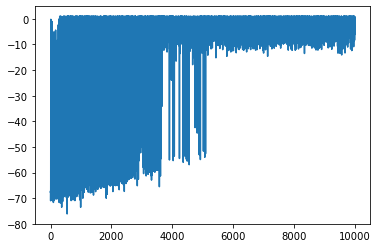

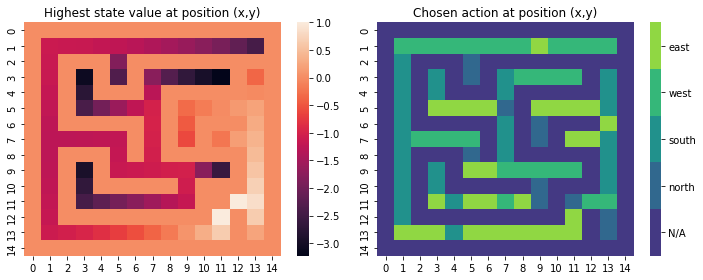

In [21]:
plt.plot(Q_learning_rewards)

visualize_agent_brain(Q_agent,env)

In [ ]:
# TODO: evaluation 
# keep the environment fixed
env = TaskEnv()

# SARSA
gamma_values = np.arange(0.01,1,0.1,dtype=float)
epsilon_values = np.arange(0.01,1,0.1,dtype=float)
alpha_values = np.arange(0.01,2,0.1,dtype=float)
results = np.zeros((gamma_values.shape[0],epsilon_values.shape[0],alpha_values.shape[0]))
for x,gamma in enumerate(gamma_values):
    for y,epsilon in enumerate(epsilon_values):
        for z,alpha in enumerate(alpha_values):
            MC_training_rewards,MC_test_rewards, MC_agent,_ = train_test(env,Monte_Carlo,epsilon,alpha,gamma,1000)
            print(f"Testing Monte Carlo agent with gamma={gamma},epsilon={epsilon},alpha={alpha}:\nResults:{MC_test_rewards}")
            results[x,y,z] = MC_test_rewards
max_results = np.argmax(results)
max_results = np.unravel_index(max_results,results.shape)
print(f"Optimal agent found with: gamma = {gamma[max_results[0]]}, epsilon = {epsilon_values[max_results[1]]}, alpha = {alpha_values[max_results[2]]}\nResults:{results.max()}")

Testing Monte Carlo agent with gamma=0.01,epsilon=0.01,alpha=0.01:
Results:-0.1978699999999999
Testing Monte Carlo agent with gamma=0.01,epsilon=0.01,alpha=0.11:
Results:-12.71103
Testing Monte Carlo agent with gamma=0.01,epsilon=0.01,alpha=0.21000000000000002:
Results:-28.52475
Testing Monte Carlo agent with gamma=0.01,epsilon=0.01,alpha=0.31000000000000005:
Results:-19.079339999999995
Testing Monte Carlo agent with gamma=0.01,epsilon=0.01,alpha=0.41000000000000003:
Results:-25.66393
Testing Monte Carlo agent with gamma=0.01,epsilon=0.01,alpha=0.51:
Results:-7.36656
Testing Monte Carlo agent with gamma=0.01,epsilon=0.01,alpha=0.6100000000000001:
Results:-20.68189
